# MetFoundation Lightweight Model: Comprehensive Analysis

This notebook demonstrates how to use the lightweight MetFoundation model to perform:
1. **Embedding Extraction**: Extract sample embeddings from metabolomic data
2. **Mortality Risk Prediction**: Predict mortality risk and calculate age acceleration
3. **Metabolic Subtype Classification**: Predict metabolic subtypes

Unlike the full MetFoundation model which uses transformer architecture and tokenization, the lightweight model uses a simpler feedforward network that directly processes normalized metabolite concentrations.

## Dataset
Data source: CHARLS (China Health and Retirement Longitudinal Study) 2011 cohort

## 1. Import Required Libraries

In [1]:
import os
import sys
import torch
import numpy as np
import pandas as pd
import anndata as ad
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle
from collections import Counter

# Add Src directory to path for importing custom modules
sys.path.append('./Src')

from metfoundation_torch.models import MetFoundation_Lightweight_Survival
from utils import set_seeds

print("="*60)
print("MetFoundation Lightweight Model - Comprehensive Analysis")
print("="*60)
print(f"\nLibraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

MetFoundation Lightweight Model - Comprehensive Analysis

Libraries imported successfully!
PyTorch version: 2.3.0
CUDA available: False
NumPy version: 2.0.2
Pandas version: 2.3.3


## 2. Configuration

Set up paths and parameters for the lightweight model analysis.

In [2]:
# Set random seed for reproducibility
set_seeds(3047)

# Configuration paths
lightweight_model_path = './Model_Weights/Lightweight/model_weights.pth'
risk2age_model_path = './Defined_Tools/Risk2AgeAccel_model.joblib'
subtype_classifier_path = './Defined_Tools/subtype_classifier.joblib'
data_path = './Data/CHARLS/charls_2011_adata.h5ad'
output_dir = './Demo_output'

# Processing parameters
batch_size = 128
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Configuration:")
print(f"  - Lightweight model: {lightweight_model_path}")
print(f"  - Risk2Age model: {risk2age_model_path}")
print(f"  - Subtype classifier: {subtype_classifier_path}")
print(f"  - Data path: {data_path}")
print(f"  - Output directory: {output_dir}")
print(f"  - Batch size: {batch_size}")
print(f"  - Device: {device}")

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Verify all files exist
print(f"\nVerifying files...")
for path, name in [(lightweight_model_path, "Lightweight model"), 
                    (risk2age_model_path, "Risk2Age model"),
                    (subtype_classifier_path, "Subtype classifier"),
                    (data_path, "Data")]:
    if os.path.exists(path):
        print(f"  ✓ {name} found")
    else:
        print(f"  ✗ {name} NOT FOUND: {path}")

Configuration:
  - Lightweight model: ./Model_Weights/Lightweight/model_weights.pth
  - Risk2Age model: ./Defined_Tools/Risk2AgeAccel_model.joblib
  - Subtype classifier: ./Defined_Tools/subtype_classifier.joblib
  - Data path: ./Data/CHARLS/charls_2011_adata.h5ad
  - Output directory: ./Demo_output
  - Batch size: 128
  - Device: cpu

Verifying files...
  ✓ Lightweight model found
  ✓ Risk2Age model found
  ✓ Subtype classifier found
  ✓ Data found


## 3. Load CHARLS Data

Load the CHARLS metabolomic data and inspect its structure.

**Note**: The lightweight model works directly with normalized metabolite concentrations, unlike the full model which requires tokenization.

In [17]:
# Load the dataset
print("Loading CHARLS 2011 data...")
adata = ad.read_h5ad(data_path)

print(f"\nData loaded successfully!")
print(f"  - Number of samples: {adata.n_obs}")
print(f"  - Number of metabolites: {adata.n_vars}")

# Inspect available metadata
print(f"\nAvailable observation metadata columns:")
for col in adata.obs.columns:
    print(f"    - {col}")

print(f"\nAvailable data layers:")
if hasattr(adata, 'layers') and len(adata.layers) > 0:
    for layer in adata.layers.keys():
        print(f"    - {layer}")
else:
    print("    - No layers found, will use .X matrix")

# Check for age column
age_cols = [col for col in adata.obs.columns if 'age' in col.lower()]
if age_cols:
    print(f"\nAge-related columns found: {age_cols}")
else:
    print(f"\nWarning: No age-related columns found")

# # Display sample info
# print(f"\nFirst few samples:")
# print(adata.obs.head())

Loading CHARLS 2011 data...

Data loaded successfully!
  - Number of samples: 11823
  - Number of metabolites: 14

Available observation metadata columns:
    - Sex
    - Chronological Age
    - BMI

Available data layers:
    - Z-score normalized

Age-related columns found: ['Chronological Age']


## 4. Prepare Data for Lightweight Model

The lightweight model requires normalized metabolite concentration data in a specific format.
We'll extract the Z-score normalized values and prepare them for batch processing.

In [4]:
# Extract normalized data
# Try to use Z-score normalized layer if available, otherwise standardize the data
if 'Z-score normalized' in adata.layers:
    print("Using existing Z-score normalized layer")
    data_matrix = adata.layers['Z-score normalized']
elif 'zscore' in adata.layers:
    print("Using existing zscore layer")
    data_matrix = adata.layers['zscore']
else:
    print("No Z-score normalized layer found, standardizing .X matrix")
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    data_matrix = scaler.fit_transform(adata.X)

# Convert to torch tensor
data_tensor = torch.FloatTensor(data_matrix)

# Handle missing values (set to 0)
data_tensor = torch.nan_to_num(data_tensor, nan=0.0)

print(f"\nData prepared for lightweight model:")
print(f"  - Shape: {data_tensor.shape}")
print(f"  - Data type: {data_tensor.dtype}")
print(f"  - Contains NaN: {torch.isnan(data_tensor).any().item()}")
print(f"  - Contains Inf: {torch.isinf(data_tensor).any().item()}")
print(f"  - Mean: {data_tensor.mean():.4f}")
print(f"  - Std: {data_tensor.std():.4f}")
print(f"  - Min: {data_tensor.min():.4f}")
print(f"  - Max: {data_tensor.max():.4f}")

# Extract age information
# Try to find age column
age_column = None
for col in adata.obs.columns:
    if 'age' in col.lower():
        age_column = col
        break

if age_column:
    ages = adata.obs[age_column].values
    print(f"\nAge information extracted from column: {age_column}")
    print(f"  - Age range: [{ages.min():.1f}, {ages.max():.1f}]")
    print(f"  - Mean age: {ages.mean():.1f}")
    print(f"  - Median age: {np.median(ages):.1f}")
    
    # Normalize age (divide by 100 as done in the original code)
    ages_normalized = ages / 100.0
else:
    print(f"\nWarning: No age column found. Using placeholder ages.")
    ages = np.ones(len(data_tensor)) * 60.0  # Placeholder
    ages_normalized = ages / 100.0

# Store sample IDs
sample_ids = adata.obs_names.tolist()
print(f"\nTotal samples to process: {len(sample_ids)}")

Using existing Z-score normalized layer

Data prepared for lightweight model:
  - Shape: torch.Size([11823, 14])
  - Data type: torch.float32
  - Contains NaN: False
  - Contains Inf: False
  - Mean: -0.1181
  - Std: 1.4433
  - Min: -15.2568
  - Max: 50.3347

Age information extracted from column: Chronological Age
  - Age range: [22.1, 99.4]
  - Mean age: 59.2
  - Median age: 58.3

Total samples to process: 11823


## 5. Load Lightweight Model

Load the pre-trained lightweight model. The lightweight model consists of:
- A simple feedforward network (3 layers with residual connections)
- A risk prediction head for mortality risk
- Optional subtype prediction head

In [5]:
# Model configuration for lightweight model
model_config = {
    'n_features': data_tensor.shape[1],  # Number of metabolites
    'd_model': 512,  # Embedding dimension
    'dropout': 0.1,
}

print(f"Lightweight model configuration:")
for key, value in model_config.items():
    print(f"  - {key}: {value}")

# Initialize the lightweight model
print(f"\nInitializing lightweight model...")
model = MetFoundation_Lightweight_Survival(model_config)
model.from_distilled(lightweight_model_path)

# # Load pre-trained weights with proper map_location
# print(f"Loading model weights from: {lightweight_model_path}")
# model_weights = torch.load(lightweight_model_path, map_location=device)

# # Load the distilled weights
# if 'DISTILLED' in model_weights:
#     model.load_state_dict(model_weights['DISTILLED'])
#     print("✓ Distilled model weights loaded successfully")
# else:
#     model.load_state_dict(model_weights)
#     print("✓ Model weights loaded successfully")

# Move model to device
model.to(device)
model.eval()

print(f"✓ Model moved to device: {device}")
print(f"✓ Model set to evaluation mode")
print(f"\nModel architecture:")
print(f"  - Lightweight encoder: 3-layer feedforward network")
print(f"  - Risk prediction head: with age fusion")
print(f"  - Subtype prediction head: {'available' if model.subtype_head is not None else 'not available'}")
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Lightweight model configuration:
  - n_features: 14
  - d_model: 512
  - dropout: 0.1

Initializing lightweight model...


✓ Model moved to device: cpu
✓ Model set to evaluation mode

Model architecture:
  - Lightweight encoder: 3-layer feedforward network
  - Risk prediction head: with age fusion
  - Subtype prediction head: not available

Total parameters: 219,521
Trainable parameters: 219,521


## 6. Extract Embeddings (Task 1)

Extract sample embeddings from the lightweight model. These embeddings are 512-dimensional representations of the metabolomic profiles.

In [6]:
print("="*60)
print("TASK 1: EMBEDDING EXTRACTION")
print("="*60)

# Function to extract embeddings in batches
def extract_embeddings_lightweight(model, data_tensor, ages_normalized, batch_size=128, device='cpu'):
    """
    Extract embeddings from the lightweight model.
    
    Args:
        model: Lightweight model
        data_tensor: Normalized metabolite data [n_samples, n_features]
        ages_normalized: Normalized age values [n_samples]
        batch_size: Batch size for processing
        device: Computing device
    
    Returns:
        embeddings: Sample embeddings [n_samples, d_model]
        risk_scores: Mortality risk scores [n_samples]
        subtype_logits: Subtype prediction logits [n_samples, n_subtypes] (if available)
    """
    model.eval()
    
    embeddings_list = []
    risk_scores_list = []
    subtype_logits_list = []
    
    n_samples = len(data_tensor)
    n_batches = (n_samples + batch_size - 1) // batch_size
    
    with torch.no_grad():
        for i in tqdm(range(n_batches), desc='Extracting embeddings'):
            # Get batch
            start_idx = i * batch_size
            end_idx = min((i + 1) * batch_size, n_samples)
            
            batch_data = data_tensor[start_idx:end_idx].to(device)
            batch_ages = torch.FloatTensor(ages_normalized[start_idx:end_idx]).to(device)
            
            # Forward pass
            outputs = model(batch_data, batch_ages)
            
            # Collect outputs
            embeddings_list.append(outputs['embs'].cpu().numpy())
            risk_scores_list.append(outputs['logit_risk'].cpu().numpy())
            
            if 'logit_subtype' in outputs:
                subtype_logits_list.append(outputs['logit_subtype'].cpu().numpy())
    
    # Concatenate all batches
    embeddings = np.concatenate(embeddings_list, axis=0)
    risk_scores = np.concatenate(risk_scores_list, axis=0).flatten()
    
    if subtype_logits_list:
        subtype_logits = np.concatenate(subtype_logits_list, axis=0)
    else:
        subtype_logits = None
    
    return embeddings, risk_scores, subtype_logits

# Extract embeddings
print("\nStarting embedding extraction...")
embeddings, risk_scores_raw, subtype_logits = extract_embeddings_lightweight(
    model, data_tensor, ages_normalized, batch_size=batch_size, device=device
)

print(f"\n✓ Embedding extraction completed!")
print(f"\nResults:")
print(f"  - Embeddings shape: {embeddings.shape}")
print(f"  - Number of samples: {embeddings.shape[0]}")
print(f"  - Embedding dimension: {embeddings.shape[1]}")
print(f"  - Risk scores shape: {risk_scores_raw.shape}")
print(f"  - Subtype logits shape: {subtype_logits.shape if subtype_logits is not None else 'N/A'}")

# Basic statistics
print(f"\nEmbedding statistics:")
print(f"  - Mean: {np.mean(embeddings):.4f}")
print(f"  - Std: {np.std(embeddings):.4f}")
print(f"  - Min: {np.min(embeddings):.4f}")
print(f"  - Max: {np.max(embeddings):.4f}")

print(f"\nRaw risk score statistics:")
print(f"  - Mean: {np.mean(risk_scores_raw):.4f}")
print(f"  - Std: {np.std(risk_scores_raw):.4f}")
print(f"  - Min: {np.min(risk_scores_raw):.4f}")
print(f"  - Max: {np.max(risk_scores_raw):.4f}")

# Check data quality
print(f"\nData quality checks:")
print(f"  - Embeddings contain NaN: {np.isnan(embeddings).any()}")
print(f"  - Embeddings contain Inf: {np.isinf(embeddings).any()}")
print(f"  - Risk scores contain NaN: {np.isnan(risk_scores_raw).any()}")
print(f"  - Risk scores contain Inf: {np.isinf(risk_scores_raw).any()}")

TASK 1: EMBEDDING EXTRACTION

Starting embedding extraction...


Extracting embeddings: 100%|██████████| 93/93 [00:01<00:00, 71.26it/s]



✓ Embedding extraction completed!

Results:
  - Embeddings shape: (11823, 512)
  - Number of samples: 11823
  - Embedding dimension: 512
  - Risk scores shape: (11823,)
  - Subtype logits shape: N/A

Embedding statistics:
  - Mean: -0.0007
  - Std: 0.4622
  - Min: -32.6025
  - Max: 24.8309

Raw risk score statistics:
  - Mean: 4.5686
  - Std: 1.3335
  - Min: 1.1781
  - Max: 14.0993

Data quality checks:
  - Embeddings contain NaN: False
  - Embeddings contain Inf: False
  - Risk scores contain NaN: False
  - Risk scores contain Inf: False


## 7. Save Embeddings

Save the extracted embeddings in multiple formats for downstream analysis.

In [7]:
# Save embeddings in multiple formats
print("\nSaving embeddings...")

# 1. Save as numpy array
embeddings_npy_path = os.path.join(output_dir, 'charls_2011_embeddings_lightweight.npy')
np.save(embeddings_npy_path, embeddings)
print(f"  ✓ Saved as numpy array: {embeddings_npy_path}")

# 2. Save as pickle with metadata
embedding_dict = {
    'embeddings': embeddings,
    'sample_ids': sample_ids,
    'n_samples': embeddings.shape[0],
    'embedding_dim': embeddings.shape[1],
    'model_config': model_config,
    'data_path': data_path,
    'model_type': 'lightweight'
}

embeddings_pkl_path = os.path.join(output_dir, 'charls_2011_embeddings_lightweight.pkl')
with open(embeddings_pkl_path, 'wb') as f:
    pickle.dump(embedding_dict, f)
print(f"  ✓ Saved as pickle with metadata: {embeddings_pkl_path}")

# 3. Save as CSV
embeddings_csv_path = os.path.join(output_dir, 'charls_2011_embeddings_lightweight.csv')
embeddings_df = pd.DataFrame(
    embeddings,
    index=sample_ids,
    columns=[f'dim_{i}' for i in range(embeddings.shape[1])]
)
embeddings_df.to_csv(embeddings_csv_path)
print(f"  ✓ Saved as CSV: {embeddings_csv_path}")

print(f"\n✓ All embeddings saved successfully!")


Saving embeddings...
  ✓ Saved as numpy array: ./Demo_output/charls_2011_embeddings_lightweight.npy
  ✓ Saved as pickle with metadata: ./Demo_output/charls_2011_embeddings_lightweight.pkl
  ✓ Saved as CSV: ./Demo_output/charls_2011_embeddings_lightweight.csv

✓ All embeddings saved successfully!


## 8. Mortality Risk Prediction and Age Acceleration (Task 2)

Convert raw risk scores to age acceleration using the debiased age gap calculator.
Age acceleration represents how much faster or slower a person is aging compared to their chronological age.

In [8]:
class DebiasedAgeGapCalculator:
    def __init__(self):
        self.risk_coef_ = None
        self.age_coef_ = None
        self.intercept_ = None
        self.is_fitted_ = False
        
    def fit(self, risk, age):
        # risk -> age
        risk2age_model = LinearRegression()
        risk2age_model.fit(risk.reshape(-1, 1), age)
        met_age = risk2age_model.predict(risk.reshape(-1, 1))
        
        # age -> met_age 
        bias_model = LinearRegression()
        bias_model.fit(age.reshape(-1, 1), met_age)
        
        # MetAgeGap = risk*β1 - age*β2 + intercept
        self.risk_coef_ = risk2age_model.coef_[0]
        self.age_coef_ = bias_model.coef_[0]  
        self.intercept_ = risk2age_model.intercept_ - bias_model.intercept_
        
        self.is_fitted_ = True
        return self
    
    def predict(self, risk, age):
        if not self.is_fitted_:
            raise ValueError("Model must be fitted first")
        
        return (self.risk_coef_ * risk - 
                self.age_coef_ * age + 
                self.intercept_)
    
    def fit_predict(self, risk, age):
        return self.fit(risk, age).predict(risk, age)
    

In [9]:
print("="*60)
print("TASK 2: MORTALITY RISK & AGE ACCELERATION")
print("="*60)

# Load Risk2Age model
print(f"\nLoading Risk2AgeAccel model...")
if not os.path.exists(risk2age_model_path):
    print(f"✗ Risk2Age model not found: {risk2age_model_path}")
    print(f"  Skipping age acceleration calculation")
    age_acceleration = None
else:
    risk2age_model = joblib.load(risk2age_model_path)
    print(f"✓ Risk2AgeAccel model loaded successfully")
    
    print(f"\nModel coefficients:")
    print(f"  - Risk coefficient: {risk2age_model.risk_coef_:.6f}")
    print(f"  - Age coefficient: {risk2age_model.age_coef_:.6f}")
    print(f"  - Intercept: {risk2age_model.intercept_:.6f}")
    
    # Calculate age acceleration
    print(f"\nCalculating age acceleration...")
    age_acceleration = risk2age_model.predict(risk_scores_raw, ages)
    
    print(f"✓ Age acceleration calculated!")
    print(f"\nAge acceleration statistics:")
    print(f"  - Mean: {age_acceleration.mean():.2f} years")
    print(f"  - Std: {age_acceleration.std():.2f} years")
    print(f"  - Min: {age_acceleration.min():.2f} years")
    print(f"  - Max: {age_acceleration.max():.2f} years")
    print(f"  - Median: {np.median(age_acceleration):.2f} years")
    
    # Percentiles
    percentiles = [10, 25, 50, 75, 90]
    age_accel_percentiles = np.percentile(age_acceleration, percentiles)
    print(f"\n  Percentiles:")
    for p, val in zip(percentiles, age_accel_percentiles):
        print(f"    {p}th: {val:.2f} years")
    
    # Categorize samples
    accelerated = np.sum(age_acceleration > 5)
    normal = np.sum((age_acceleration >= -5) & (age_acceleration <= 5))
    decelerated = np.sum(age_acceleration < -5)
    
    print(f"\nAge acceleration categories:")
    print(f"  - Accelerated aging (>5 years): {accelerated} ({100*accelerated/len(age_acceleration):.1f}%)")
    print(f"  - Normal aging (-5 to 5 years): {normal} ({100*normal/len(age_acceleration):.1f}%)")
    print(f"  - Decelerated aging (<-5 years): {decelerated} ({100*decelerated/len(age_acceleration):.1f}%)")
    
    # Correlation analysis
    print(f"\nCorrelation analysis:")
    corr_risk_age = np.corrcoef(risk_scores_raw, ages)[0, 1]
    corr_accel_age = np.corrcoef(age_acceleration, ages)[0, 1]
    corr_risk_accel = np.corrcoef(risk_scores_raw, age_acceleration)[0, 1]
    print(f"  - Risk score vs Chronological age: {corr_risk_age:.4f}")
    print(f"  - Age acceleration vs Chronological age: {corr_accel_age:.4f}")
    print(f"  - Risk score vs Age acceleration: {corr_risk_accel:.4f}")

TASK 2: MORTALITY RISK & AGE ACCELERATION

Loading Risk2AgeAccel model...
✓ Risk2AgeAccel model loaded successfully

Model coefficients:
  - Risk coefficient: 7.214727
  - Age coefficient: 0.684350
  - Intercept: 11.552841

Calculating age acceleration...
✓ Age acceleration calculated!

Age acceleration statistics:
  - Mean: 3.98 years
  - Std: 5.45 years
  - Min: -9.13 years
  - Max: 75.24 years
  - Median: 3.38 years

  Percentiles:
    10th: -2.28 years
    25th: 0.15 years
    50th: 3.38 years
    75th: 7.00 years
    90th: 10.83 years

Age acceleration categories:
  - Accelerated aging (>5 years): 4450 (37.6%)
  - Normal aging (-5 to 5 years): 7160 (60.6%)
  - Decelerated aging (<-5 years): 213 (1.8%)

Correlation analysis:
  - Risk score vs Chronological age: 0.8359
  - Age acceleration vs Chronological age: 0.2480
  - Risk score vs Age acceleration: 0.7391


## 9. Visualize Mortality Risk and Age Acceleration

Create visualizations to understand the relationships between age, risk, and biological aging.

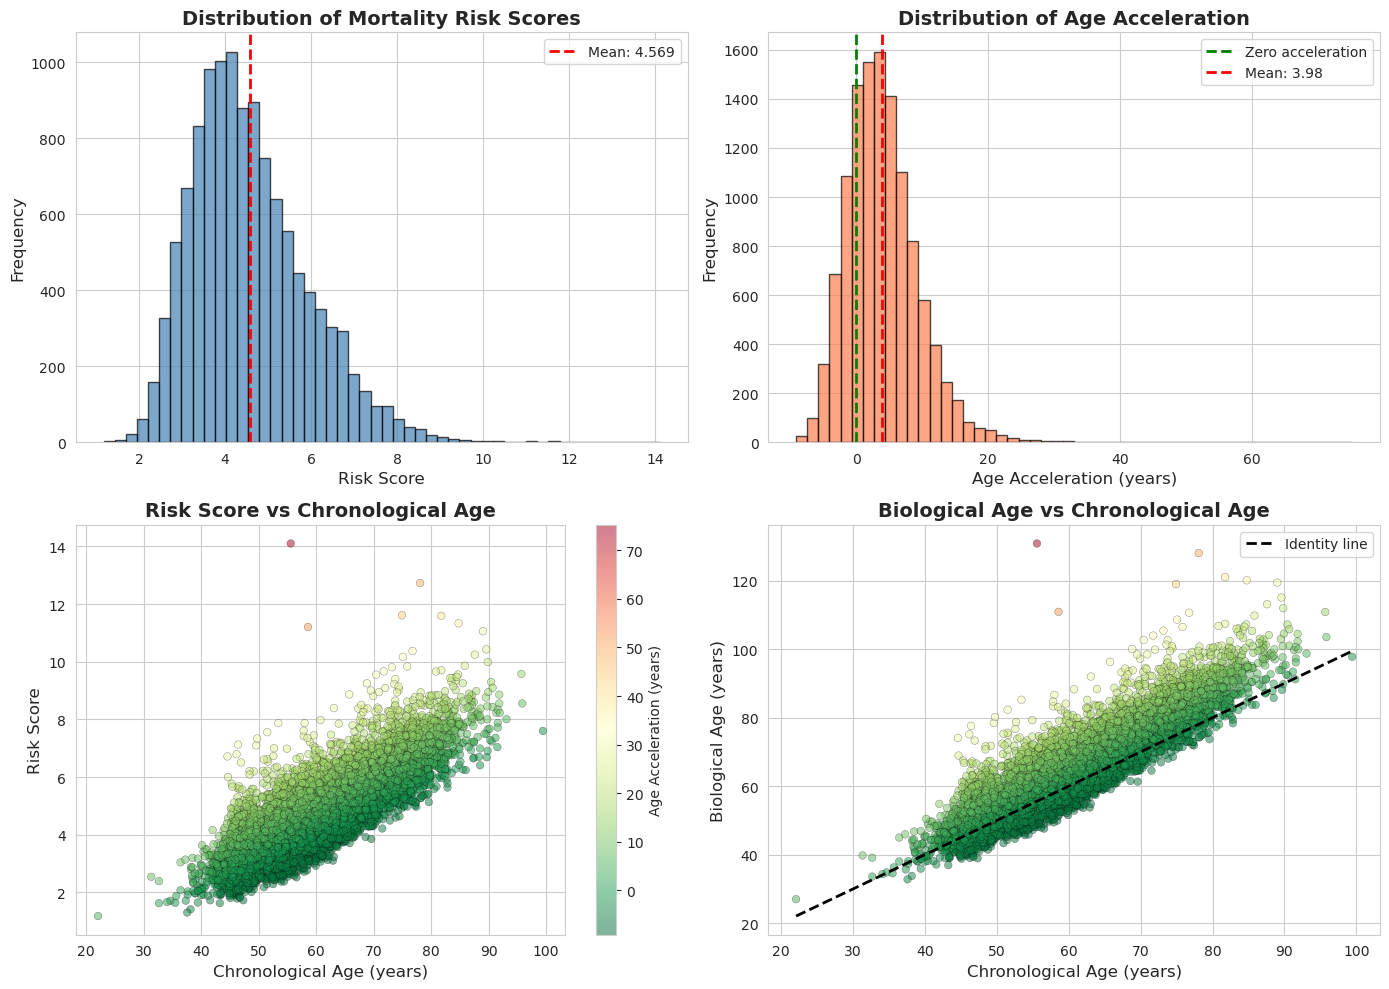

In [10]:
if age_acceleration is not None:
    # Set up plotting style
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Risk Score Distribution
    axes[0, 0].hist(risk_scores_raw, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Risk Score', fontsize=12)
    axes[0, 0].set_ylabel('Frequency', fontsize=12)
    axes[0, 0].set_title('Distribution of Mortality Risk Scores', fontsize=14, fontweight='bold')
    axes[0, 0].axvline(risk_scores_raw.mean(), color='red', linestyle='--', linewidth=2, 
                       label=f'Mean: {risk_scores_raw.mean():.3f}')
    axes[0, 0].legend()
    
    # Plot 2: Age Acceleration Distribution
    axes[0, 1].hist(age_acceleration, bins=50, color='coral', edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Age Acceleration (years)', fontsize=12)
    axes[0, 1].set_ylabel('Frequency', fontsize=12)
    axes[0, 1].set_title('Distribution of Age Acceleration', fontsize=14, fontweight='bold')
    axes[0, 1].axvline(0, color='green', linestyle='--', linewidth=2, label='Zero acceleration')
    axes[0, 1].axvline(age_acceleration.mean(), color='red', linestyle='--', linewidth=2, 
                       label=f'Mean: {age_acceleration.mean():.2f}')
    axes[0, 1].legend()
    
    # Plot 3: Risk vs Chronological Age
    scatter = axes[1, 0].scatter(ages, risk_scores_raw, c=age_acceleration, cmap='RdYlGn_r', 
                                alpha=0.5, s=30, edgecolors='black', linewidth=0.3)
    axes[1, 0].set_xlabel('Chronological Age (years)', fontsize=12)
    axes[1, 0].set_ylabel('Risk Score', fontsize=12)
    axes[1, 0].set_title('Risk Score vs Chronological Age', fontsize=14, fontweight='bold')
    cbar = plt.colorbar(scatter, ax=axes[1, 0])
    cbar.set_label('Age Acceleration (years)', fontsize=10)
    
    # Plot 4: Biological Age vs Chronological Age
    biological_age = ages + age_acceleration
    axes[1, 1].scatter(ages, biological_age, alpha=0.5, s=30, 
                       c=age_acceleration, cmap='RdYlGn_r', edgecolors='black', linewidth=0.3)
    axes[1, 1].plot([ages.min(), ages.max()], [ages.min(), ages.max()], 
                    'k--', linewidth=2, label='Identity line')
    axes[1, 1].set_xlabel('Chronological Age (years)', fontsize=12)
    axes[1, 1].set_ylabel('Biological Age (years)', fontsize=12)
    axes[1, 1].set_title('Biological Age vs Chronological Age', fontsize=14, fontweight='bold')
    axes[1, 1].legend()
    
    plt.tight_layout()
    
    # Save figure
    fig_path = os.path.join(output_dir, 'charls_2011_mortality_age_acceleration.png')
    # plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    # print(f"\n✓ Visualization saved: {fig_path}")
    plt.show()
else:
    print("\nSkipping visualization (no age acceleration data)")

## 10. Metabolic Subtype Prediction (Task 3)

Predict metabolic subtypes using the trained classifier on the extracted embeddings.

In [11]:
print("="*60)
print("TASK 3: METABOLIC SUBTYPE PREDICTION")
print("="*60)

# Load subtype classifier
print(f"\nLoading metabolic subtype classifier...")
if not os.path.exists(subtype_classifier_path):
    print(f"✗ Subtype classifier not found: {subtype_classifier_path}")
    print(f"  Skipping subtype prediction")
    predicted_subtypes = None
else:
    try:
        subtype_classifier = joblib.load(subtype_classifier_path)
        print(f"✓ Subtype classifier loaded successfully")
        
        # Display classifier information
        print(f"\nClassifier information:")
        print(f"  - Classifier type: {type(subtype_classifier).__name__}")
        
        if hasattr(subtype_classifier, 'classes_'):
            print(f"  - Number of subtypes: {len(subtype_classifier.classes_)}")
            print(f"  - Subtype labels: {subtype_classifier.classes_}")
        
        if hasattr(subtype_classifier, 'n_features_in_'):
            print(f"  - Expected number of features: {subtype_classifier.n_features_in_}")
        
        # Predict subtypes
        print(f"\nPredicting metabolic subtypes...")
        predicted_subtypes = subtype_classifier.predict(embeddings)
        
        print(f"✓ Subtype prediction completed!")
        print(f"\nPrediction results:")
        print(f"  - Total predictions: {len(predicted_subtypes)}")
        print(f"  - Unique subtypes predicted: {len(np.unique(predicted_subtypes))}")
        print(f"  - Subtype values: {sorted(np.unique(predicted_subtypes))}")
        
        # Get prediction probabilities if available
        if hasattr(subtype_classifier, 'predict_proba'):
            prediction_probs = subtype_classifier.predict_proba(embeddings)
            max_probs = np.max(prediction_probs, axis=1)
            print(f"\nPrediction confidence:")
            print(f"  - Average max probability: {max_probs.mean():.4f}")
            print(f"  - Min max probability: {max_probs.min():.4f}")
            print(f"  - Max max probability: {max_probs.max():.4f}")
        else:
            prediction_probs = None
            print(f"\n  - Prediction probabilities not available for this classifier type")
            
    except Exception as e:
        print(f"✗ Error loading or using subtype classifier: {e}")
        predicted_subtypes = None
        prediction_probs = None

TASK 3: METABOLIC SUBTYPE PREDICTION

Loading metabolic subtype classifier...


✓ Subtype classifier loaded successfully

Classifier information:
  - Classifier type: MLPClassifier
  - Number of subtypes: 13
  - Subtype labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
  - Expected number of features: 512

Predicting metabolic subtypes...
✓ Subtype prediction completed!

Prediction results:
  - Total predictions: 11823
  - Unique subtypes predicted: 13
  - Subtype values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

Prediction confidence:
  - Average max probability: 0.8890
  - Min max probability: 0.2083
  - Max max probability: 1.0000


## 11. Analyze Subtype Distribution

Analyze the distribution of predicted metabolic subtypes.

In [12]:
if predicted_subtypes is not None:
    # Count subtype distribution
    subtype_counts = Counter(predicted_subtypes)
    subtype_df = pd.DataFrame({
        'Subtype': list(subtype_counts.keys()),
        'Count': list(subtype_counts.values())
    }).sort_values('Subtype')
    
    # Calculate percentages
    subtype_df['Percentage'] = (subtype_df['Count'] / len(predicted_subtypes) * 100).round(2)
    
    print("\n" + "="*60)
    print("Metabolic Subtype Distribution")
    print("="*60)
    print(subtype_df.to_string(index=False))
    
    # Summary statistics
    print(f"\nSummary:")
    print(f"  - Total samples: {len(predicted_subtypes)}")
    print(f"  - Number of unique subtypes: {len(subtype_counts)}")
    print(f"  - Most common subtype: {subtype_df.iloc[subtype_df['Count'].argmax()]['Subtype']} "
          f"({subtype_df['Count'].max()} samples, {subtype_df['Percentage'].max():.2f}%)")
    print(f"  - Least common subtype: {subtype_df.iloc[subtype_df['Count'].argmin()]['Subtype']} "
          f"({subtype_df['Count'].min()} samples, {subtype_df['Percentage'].min():.2f}%)")
else:
    print("\nSkipping subtype distribution analysis (no predictions)")


Metabolic Subtype Distribution
 Subtype  Count  Percentage
       0   1123        9.50
       1   2358       19.94
       2    644        5.45
       3   2609       22.07
       4   2832       23.95
       5   1418       11.99
       6    149        1.26
       7     76        0.64
       8    242        2.05
       9    152        1.29
      10     16        0.14
      11    189        1.60
      12     15        0.13

Summary:
  - Total samples: 11823
  - Number of unique subtypes: 13
  - Most common subtype: 4.0 (2832 samples, 23.95%)
  - Least common subtype: 12.0 (15 samples, 0.13%)


## 12. Visualize Subtype Distribution

Create visualizations for the metabolic subtype distribution.


✓ Subtype distribution visualization saved: ./Demo_output/charls_2011_mortality_age_acceleration.png


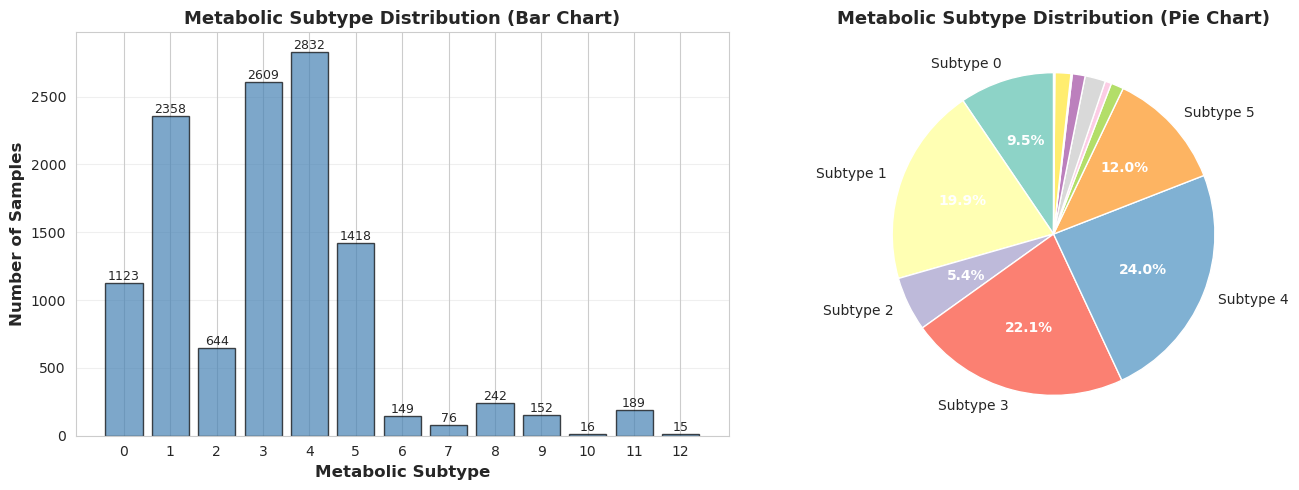

In [13]:
if predicted_subtypes is not None:
    # Set plotting style
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Bar chart
    ax1 = axes[0]
    bars = ax1.bar(subtype_df['Subtype'].astype(str), subtype_df['Count'], 
                   color='steelblue', alpha=0.7, edgecolor='black')
    ax1.set_xlabel('Metabolic Subtype', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
    ax1.set_title('Metabolic Subtype Distribution (Bar Chart)', fontsize=13, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}',
                 ha='center', va='bottom', fontsize=9)
    
    # Plot 2: Pie chart
    ax2 = axes[1]
    colors = sns.color_palette('Set3', len(subtype_df))
    
    # Calculate percentages and create labels
    percentages = (subtype_df['Count'] / len(predicted_subtypes) * 100).values
    labels = [f'Subtype {s}' if pct >= 5 else '' 
              for s, pct in zip(subtype_df['Subtype'], percentages)]
    
    def autopct_format(pct):
        return f'{pct:.1f}%' if pct >= 5 else ''
    
    wedges, texts, autotexts = ax2.pie(subtype_df['Count'], 
                                         labels=labels, 
                                         autopct=autopct_format,
                                         colors=colors,
                                         startangle=90,
                                         textprops={'fontsize': 10})
    ax2.set_title('Metabolic Subtype Distribution (Pie Chart)', fontsize=13, fontweight='bold')
    
    # Make percentage text bold
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    plt.tight_layout()
    
    # Save figure
    # fig_path = os.path.join(output_dir, 'charls_2011_subtype_distribution.png')
    # plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Subtype distribution visualization saved: {fig_path}")
    plt.show()
else:
    print("\nSkipping subtype visualization (no predictions)")

## 13. Meta-Subtype Grouping

Convert fine-grained subtypes to meta-subtypes for hierarchical analysis.

In [14]:
if predicted_subtypes is not None:
    # Define meta-subtype mapping
    meta_subtypes = {
        1: [8],
        2: [0, 5, 2, 3],
        3: [6, 9, 12, 7, 10],
        4: [4, 1, 11]
    }
    
    # Create mapping dictionary
    subtype_to_meta = {}
    for meta_subtype, subtypes in meta_subtypes.items():
        for subtype in subtypes:
            subtype_to_meta[subtype] = meta_subtype
    
    print("\nSubtype to Meta-subtype mapping:")
    for subtype in sorted(subtype_to_meta.keys()):
        print(f"  Subtype {subtype} -> Meta-subtype {subtype_to_meta[subtype]}")
    
    # Convert to meta-subtypes
    predicted_meta_subtypes = np.array([subtype_to_meta.get(s, -1) for s in predicted_subtypes])
    
    # Check for unmapped subtypes
    unmapped = predicted_meta_subtypes == -1
    if unmapped.any():
        print(f"\nWarning: {unmapped.sum()} samples have unmapped subtypes")
        print(f"  Unmapped subtype values: {np.unique(predicted_subtypes[unmapped])}")
    
    # Count meta-subtype distribution
    meta_subtype_counts = Counter(predicted_meta_subtypes[~unmapped])
    meta_subtype_df = pd.DataFrame({
        'Meta_Subtype': list(meta_subtype_counts.keys()),
        'Count': list(meta_subtype_counts.values())
    }).sort_values('Meta_Subtype')
    
    # Calculate percentages
    meta_subtype_df['Percentage'] = (meta_subtype_df['Count'] / len(predicted_meta_subtypes[~unmapped]) * 100).round(2)
    
    print("\n" + "="*60)
    print("Metabolic Meta-Subtype Distribution")
    print("="*60)
    print(meta_subtype_df.to_string(index=False))
    
    print(f"\nSummary:")
    print(f"  - Total samples: {len(predicted_meta_subtypes[~unmapped])}")
    print(f"  - Number of unique meta-subtypes: {len(meta_subtype_counts)}")
else:
    print("\nSkipping meta-subtype analysis (no predictions)")
    predicted_meta_subtypes = None


Subtype to Meta-subtype mapping:
  Subtype 0 -> Meta-subtype 2
  Subtype 1 -> Meta-subtype 4
  Subtype 2 -> Meta-subtype 2
  Subtype 3 -> Meta-subtype 2
  Subtype 4 -> Meta-subtype 4
  Subtype 5 -> Meta-subtype 2
  Subtype 6 -> Meta-subtype 3
  Subtype 7 -> Meta-subtype 3
  Subtype 8 -> Meta-subtype 1
  Subtype 9 -> Meta-subtype 3
  Subtype 10 -> Meta-subtype 3
  Subtype 11 -> Meta-subtype 4
  Subtype 12 -> Meta-subtype 3

Metabolic Meta-Subtype Distribution
 Meta_Subtype  Count  Percentage
            1    242        2.05
            2   5794       49.01
            3    408        3.45
            4   5379       45.50

Summary:
  - Total samples: 11823
  - Number of unique meta-subtypes: 4


## 14. Create Comprehensive Results DataFrame

Combine all predictions and analyses into a single dataframe.

In [15]:
# Create comprehensive results dataframe
results_df = pd.DataFrame({
    'sample_id': sample_ids,
    'chronological_age': ages,
})

# Add risk scores
results_df['risk_score'] = risk_scores_raw

# Add age acceleration if available
if age_acceleration is not None:
    results_df['age_acceleration'] = age_acceleration
    results_df['biological_age'] = ages + age_acceleration

# Add subtype predictions if available
if predicted_subtypes is not None:
    results_df['predicted_subtype'] = predicted_subtypes
    
    if predicted_meta_subtypes is not None:
        results_df['predicted_meta_subtype'] = predicted_meta_subtypes
    
    # Add prediction probabilities if available
    if prediction_probs is not None:
        for i, class_label in enumerate(subtype_classifier.classes_):
            results_df[f'prob_subtype_{class_label}'] = prediction_probs[:, i]
        results_df['prediction_confidence'] = np.max(prediction_probs, axis=1)

print("\n" + "="*60)
print("COMPREHENSIVE RESULTS DATAFRAME")
print("="*60)
print(f"\nDataframe shape: {results_df.shape}")
print(f"\nColumn names:")
for i, col in enumerate(results_df.columns, 1):
    print(f"  {i}. {col}")

# print(f"\nFirst 10 samples:")
# print(results_df.head(10).to_string())

# print(f"\nData summary:")
# print(results_df.describe())


COMPREHENSIVE RESULTS DATAFRAME

Dataframe shape: (11823, 21)

Column names:
  1. sample_id
  2. chronological_age
  3. risk_score
  4. age_acceleration
  5. biological_age
  6. predicted_subtype
  7. predicted_meta_subtype
  8. prob_subtype_0
  9. prob_subtype_1
  10. prob_subtype_2
  11. prob_subtype_3
  12. prob_subtype_4
  13. prob_subtype_5
  14. prob_subtype_6
  15. prob_subtype_7
  16. prob_subtype_8
  17. prob_subtype_9
  18. prob_subtype_10
  19. prob_subtype_11
  20. prob_subtype_12
  21. prediction_confidence


## 15. Save All Results

Save all predictions and analyses for downstream use.

In [16]:
print("\n" + "="*60)
print("SAVING ALL RESULTS")
print("="*60)

# Save comprehensive results CSV
results_csv_path = os.path.join(output_dir, 'charls_2011_comprehensive_results_lightweight.csv')
results_df.to_csv(results_csv_path, index=False)
print(f"\n✓ Comprehensive results saved: {results_csv_path}")

# Save subtype distribution if available
if predicted_subtypes is not None:
    subtype_dist_path = os.path.join(output_dir, 'charls_2011_subtype_distribution.csv')
    subtype_df.to_csv(subtype_dist_path, index=False)
    print(f"✓ Subtype distribution saved: {subtype_dist_path}")
    
    if predicted_meta_subtypes is not None:
        meta_subtype_dist_path = os.path.join(output_dir, 'charls_2011_meta_subtype_distribution.csv')
        meta_subtype_df.to_csv(meta_subtype_dist_path, index=False)
        print(f"✓ Meta-subtype distribution saved: {meta_subtype_dist_path}")
        
        # Save mapping
        mapping_df = pd.DataFrame([
            {'Subtype': k, 'Meta_Subtype': v} 
            for k, v in sorted(subtype_to_meta.items())
        ])
        mapping_path = os.path.join(output_dir, 'subtype_to_meta_mapping.csv')
        mapping_df.to_csv(mapping_path, index=False)
        print(f"✓ Subtype-to-meta-subtype mapping saved: {mapping_path}")

print(f"\n✓ All results saved successfully in: {output_dir}")
print("\nSaved files:")
for filename in os.listdir(output_dir):
    if 'charls_2011' in filename:
        filepath = os.path.join(output_dir, filename)
        size = os.path.getsize(filepath) / 1024  # Size in KB
        print(f"  - {filename} ({size:.1f} KB)")


SAVING ALL RESULTS

✓ Comprehensive results saved: ./Demo_output/charls_2011_comprehensive_results_lightweight.csv
✓ Subtype distribution saved: ./Demo_output/charls_2011_subtype_distribution.csv
✓ Meta-subtype distribution saved: ./Demo_output/charls_2011_meta_subtype_distribution.csv
✓ Subtype-to-meta-subtype mapping saved: ./Demo_output/subtype_to_meta_mapping.csv

✓ All results saved successfully in: ./Demo_output

Saved files:
  - charls_2011_embeddings_lightweight.npy (23646.1 KB)
  - charls_2011_embeddings_lightweight.pkl (23819.6 KB)
  - charls_2011_embeddings_lightweight.csv (67949.3 KB)
  - charls_2011_comprehensive_results_lightweight.csv (2846.0 KB)
  - charls_2011_subtype_distribution.csv (0.2 KB)
  - charls_2011_meta_subtype_distribution.csv (0.1 KB)


## 16. Summary and Comparison with Full Model

### Summary

This notebook demonstrated the use of the **lightweight MetFoundation model** for comprehensive metabolomic analysis on CHARLS 2011 data:

#### Tasks Completed:
1. ✓ **Embedding Extraction**: Extracted 512-dimensional embeddings for all samples
2. ✓ **Mortality Risk Prediction**: Predicted mortality risk scores and calculated age acceleration
3. ✓ **Metabolic Subtype Classification**: Classified samples into metabolic subtypes and meta-subtypes

#### Key Differences from Full Model:

| Aspect | Full MetFoundation Model | Lightweight Model |
|--------|-------------------------|-------------------|
| **Architecture** | Transformer-based (multi-head attention) | Simple feedforward network (3 layers) |
| **Input Processing** | Requires tokenization of metabolites | Direct input of normalized concentrations |
| **Model Size** | ~20M parameters | <1M parameters |
| **Inference Speed** | Slower (attention mechanism) | Much faster (simple forward pass) |
| **Memory Usage** | Higher | Lower |
| **Use Case** | Research, detailed analysis | Deployment, real-time prediction |


### Output Files

All results saved in `./Demo_output/`:
- `charls_2011_embeddings_lightweight.{npy,pkl,csv}`: Extracted embeddings
- `charls_2011_comprehensive_results_lightweight.csv`: Complete analysis results
- `charls_2011_subtype_distribution.csv`: Subtype distribution summary
- `charls_2011_meta_subtype_distribution.csv`: Meta-subtype distribution
- `charls_2011_mortality_age_acceleration.png`: Risk and age acceleration visualizations
- `charls_2011_subtype_distribution.png`: Subtype distribution visualizations

### Next Steps

You can use these results for:
1. **Epidemiological studies**: Compare aging patterns across populations
2. **Biomarker discovery**: Identify metabolites associated with subtypes
3. **Longitudinal analysis**: Track changes over time (compare with CHARLS 2015)
4. **Clinical translation**: Apply lightweight model in clinical settings
5. **Cross-cohort validation**: Compare with UKB or other cohorts

### Citation

If you use MetFoundation in your research, please cite the original paper.

---
**End of Comprehensive Analysis**